# ISO 20414:2020 — Test 5: Assigned occupant demographics

100 occupants evenly distributed in a 100 m x 100 m room with desired speeds sampled from a distribution (here Gaussian mu=1.2, sigma=0.2) (ISO 20414:2020 Table 6). The verification target is consistency between the assigned and the **represented** walking-speed distribution, so we run the scenario, measure each agent's free-flow speed from its trajectory, and compare it back to the assigned Gaussian.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 07 July 2026, 19:13 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and inspect the scenario

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-05-demographics.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
params = scenario.distributions['jps-distributions_0']['parameters']
print(f'v0 = {params["v0"]} m/s, v0_distribution = {params["v0_distribution"]}, '
      f'v0_std = {params.get("v0_std", "n/a")}, n = {params["number"]}')

v0 = 1.2 m/s, v0_distribution = gaussian, v0_std = 0.2, n = 100


## Run and measure the represented walking speeds

The base scenario has no exit, so agents never move. We add a full-width exit on the far wall and let the crowd walk across the room. At the ISO density (100 agents in 100 m x 100 m = 0.01 p/m²) every agent is in free flow, so its measured speed equals its assigned desired speed. Per ISO the test is repeated over several runs; for each agent we take the median instantaneous speed over the frames where it is moving.

In [5]:
MU, SIGMA = params['v0'], params['v0_std']
N_RUNS = 5
SEEDS = [42 + i for i in range(N_RUNS)]
assigned = np.random.default_rng(0).normal(MU, SIGMA, 100000)  # the assigned distribution


def measure_free_flow_speeds(seed):
    s = load_scenario(str(SCENARIO_ZIP))
    # No exit in the base scenario -> add a full-width exit on the far (x=100)
    # wall so the sparse crowd walks across the room in free flow.
    s.add_exit([(100, 0), (100, 100), (99.7, 100), (99.7, 0)])
    result = run_scenario(s, seed=seed)
    traj = result.trajectory_dataframe().sort_values(['id', 'frame'])
    fr = result.frame_rate
    speeds = []
    for _, sub in traj.groupby('id'):
        step = np.hypot(np.diff(sub.x), np.diff(sub.y)) * fr  # m/s per frame
        step = step[step > 0.05]                              # frames where moving
        if len(step):
            speeds.append(np.median(step))
    result.cleanup()
    return np.array(speeds)


rows, all_speeds = [], []
for seed in SEEDS:
    sp = measure_free_flow_speeds(seed)
    all_speeds.append(sp)
    rows.append({'seed': seed, 'n': len(sp), 'mean': sp.mean(),
                 'std': sp.std(), 'ks_p': stats.ks_2samp(sp, assigned).pvalue})
fit = pd.DataFrame(rows)
all_speeds = np.concatenate(all_speeds)
fit

,seed,n,mean,std,ks_p
0,42,100,1.178506,0.181167,0.205073
1,43,100,1.212917,0.192058,0.942699
2,44,100,1.182059,0.200427,0.924108
3,45,100,1.172164,0.186192,0.067124
4,46,100,1.186644,0.183767,0.213334


## Represented speeds vs the assigned Gaussian

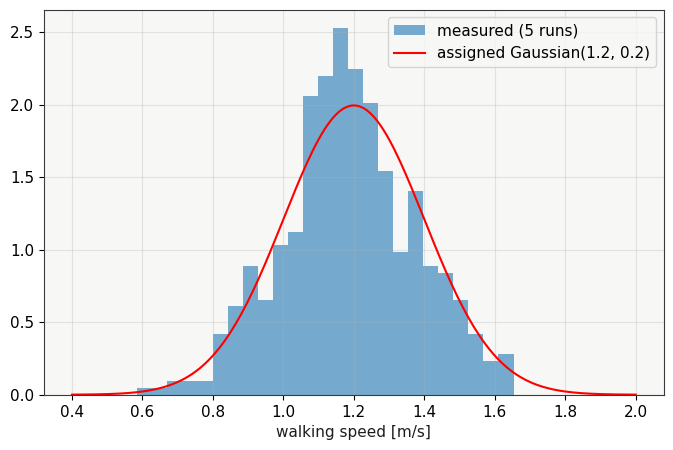

In [6]:
fig, ax = plt.subplots()
ax.hist(all_speeds, bins=25, density=True, alpha=0.6, label=f'measured ({N_RUNS} runs)')
xs = np.linspace(0.4, 2.0, 200)
ax.plot(xs, (1 / (SIGMA * np.sqrt(2 * np.pi)))
        * np.exp(-0.5 * ((xs - MU) / SIGMA) ** 2), 'r-', label=f'assigned Gaussian({MU}, {SIGMA})')
ax.set_xlabel('walking speed [m/s]'); ax.legend()
plt.show()

## Acceptance

The represented walking-speed distribution must be consistent with the assigned Gaussian(1.2, 0.2): the pooled mean and standard deviation match the assigned parameters within tolerance, and the per-run shape is Gaussian-consistent (median two-sample KS p > 0.05). A small (~1%) downward offset in the measured mean is a model-level free-flow characteristic, not a distribution mismatch.

In [7]:
ALPHA = 0.05
assert params['v0_distribution'] == 'gaussian'
assert abs(all_speeds.mean() - MU) < 0.05, all_speeds.mean()
assert abs(all_speeds.std() - SIGMA) < 0.05, all_speeds.std()
assert fit['ks_p'].median() > ALPHA, fit
print(f'PASS - represented speeds match assigned Gaussian({MU}, {SIGMA}) over {N_RUNS} runs: '
      f'mean={all_speeds.mean():.3f}, std={all_speeds.std():.3f}, median KS p={fit["ks_p"].median():.3f}')

PASS - represented speeds match assigned Gaussian(1.2, 0.2) over 5 runs: mean=1.186, std=0.189, median KS p=0.213
